# **Business Case 1: Segmenting Clients - Insurance**

This Section is specifically dedicated at finding the clusters that best describe the **personas to whom to sell insurance**. 


In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import prince
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)

In [3]:
# Drop the column ID
data = data.drop(columns=['ID']) 
data.head()

,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Preparing data
We extract the variables of interest, also dividing into:
* **Numerical**.
* **Categorical** (excluding the ID, which is not informative at this level).


We have to:
* **Encode categorical variables**, so that they can be digestible by clustering algorithms - they are all trasformed in boolean variables by one-hot encoding.
* **Normalize** in [0, 1] numerical variables.

## Outlier Analysis

In [4]:
def find_outliers_selective(df, columns_to_check):
    """
    df: Your pandas DataFrame
    columns_to_check: List of strings (names of continuous numerical columns)
    """
    rows_to_drop = set()
    
    for col in columns_to_check:
        data = df[col].values
        mean, std = data.mean(), data.std()
        
        # 3-sigma rule
        lower, upper = mean - 3*std, mean + 3*std
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        if not outliers.empty:
            print(f"Feature '{col}' has {len(outliers)} outliers.")
            rows_to_drop.update(outliers.index.tolist())
            
    # Drop rows by index
    df_cleaned = df.drop(index=list(rows_to_drop))
    print(f"\nDropped {len(rows_to_drop)} total rows.")
    return df_cleaned

# Usage: Only pass Age or Family Members, NOT Gender/Occupation/Percentiles
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
continuous_cols =  [col for col in data.columns if col not in categorical_cols]
data = find_outliers_selective(data, continuous_cols)

Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.


# Setup for Insurance + FADM

For the insurance clusters, the datas that do make sense to include, when used in a "raw" state return only around 37% of variance explained with FAMD which isn't optimal to draw conclusions from. We therefore decided to implement ratios instead of variables that are qualitatively correlated (might not show up in the dataset but would make sense for them to be) and create ratios.

In [5]:
# Create the ratios and add an infinitesimal amount to avoid errors from the div by 0
data['Debt_to_Income'] = data['Debt'] / (data['Income'] + 0.0001) 
data['Safety_Net'] = (data['Wealth'] + data['Saving']) / (data['Income'] + 0.0001)
data['Dependents_Risk'] = data['FamilySize'] / data['Age']
data['Asset_Exposure'] = data['Luxury'] / (data['Income'] + 0.0001)

# Re-trim the dataset from outliers
data['Debt_to_Income'] = data['Debt_to_Income'].clip(upper=5)
data['Safety_Net'] = data['Safety_Net'].clip(upper=5)
data['Dependents_Risk'] = data['Dependents_Risk'].clip(upper=5)
data['Asset_Exposure'] = data['Asset_Exposure'].clip(upper=5)

# We define the "risk engine"
active_risk_cols = [
    'Debt_to_Income', 
    'Safety_Net', 
    'Dependents_Risk', 
    'Asset_Exposure', 
    'FinEdu', 
    'Job'
]
df_active_mixed = data[active_risk_cols].copy()

# Initialize and Fit FAMD
famd = prince.FAMD(
    n_components=3, #dims to reduce to
    n_iter=10, #coordinate optimization max iter
    copy=True,
    check_input=True,
    engine='sklearn', #lib
    random_state=42 #seed
)

# Transform the mixed data into pure continuous coordinates
X_famd = famd.fit_transform(df_active_mixed)
X_famd.columns = ['Dim_1', 'Dim_2', 'Dim_3']

print("\nFAMD Continuous Coordinates (Ready for Clustering):")
display(X_famd.head(3))

#  Check the Variance Explained
explained_variance = famd.percentage_of_variance_

# The newer library outputs actual percentages (e.g., 45.2 instead of 0.452)
# We do a quick check to see if we need to multiply by 100
total_var = sum(explained_variance)
if total_var <= 1.0:
    total_var *= 100
    explained_variance = [v * 100 for v in explained_variance]

print(f"\nTotal Variance Explained by 3 Dimensions: {total_var:.2f}%")


FAMD Continuous Coordinates (Ready for Clustering):


,Dim_1,Dim_2,Dim_3
0,-0.193926,2.103062,2.013974
1,0.193765,1.283705,-1.556866
2,-0.772939,0.208092,0.129753



Total Variance Explained by 3 Dimensions: 61.12%


# Interpretation of FAMD

Let's understand what the new Continuous Dimensions created by FAMD actually represent. We can do this by identifying which features they are composed of and analyzing their correlations.

1. **Feature Contributions**: Understanding how much each original variable "weighs" in the creation of each new dimension.

2. **Normalized Feature Contributions**

3. **Feature Correlations**: The relationship between the new dimensions and the variables that compose them.

In [6]:
# Extract the column contributions to each FAMD dimension
contributions = famd.column_contributions_.style.format("{:.2%}")
print("--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---")
display(contributions)

# Extract the raw numbers from the Styler object
raw_contributions = contributions.data

# Now perform the math on the raw dataframe to force it to 100%
normalized_contributions = (raw_contributions.div(raw_contributions.sum(axis=0), axis=1)) * 100

print("--- NORMALIZED FEATURE CONTRIBUTIONS ---")
display(normalized_contributions.round(2).astype(str) + '%')


# Extract column correlations
row_coordinates = famd.transform(df_active_mixed)
numerical_cols = df_active_mixed.select_dtypes(include=['number']).columns

# Calculate correlation between original numerical data and FAMD dimensions
correlations = df_active_mixed[numerical_cols].apply(lambda x: row_coordinates.corrwith(x))

print("\n--- FEATURE CORRELATIONS WITH DIMENSIONS (MANUAL) ---")
display(correlations.round(3))


--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---


component,0,1,2
variable,,,
Debt_to_Income,32.90%,1.44%,0.00%
Safety_Net,33.84%,5.82%,0.02%
Dependents_Risk,0.64%,20.04%,71.45%
Asset_Exposure,31.56%,0.33%,0.95%
FinEdu,0.18%,56.37%,24.85%
Job,1.76%,32.00%,5.44%


--- NORMALIZED FEATURE CONTRIBUTIONS ---


component,0,1,2
variable,,,
Debt_to_Income,32.62%,1.24%,0.0%
Safety_Net,33.55%,5.02%,0.02%
Dependents_Risk,0.63%,17.28%,69.56%
Asset_Exposure,31.28%,0.28%,0.93%
FinEdu,0.17%,48.6%,24.19%
Job,1.75%,27.58%,5.3%



--- FEATURE CORRELATIONS WITH DIMENSIONS (MANUAL) ---


,Debt_to_Income,Safety_Net,Dependents_Risk,Asset_Exposure,FinEdu,Job
component,,,,,,
0,0.829,0.841,0.115,0.812,0.061,-0.114
1,0.131,-0.264,0.489,-0.062,0.821,-0.477
2,0.007,0.015,0.842,-0.097,-0.497,-0.106


# Interpretation of FAMD

Analyzing the results for the 3 components, we notice:

* **Component 0 (Dim1)** -> Positive correlation with *Debt*, *Saving*, and *Asset Exposure*; represents financial exposure.

* **Component 1 (Dim2)** -> Positive correlation with *FinEdu* and negative with *Job*; represents financial literacy.

* **Component 2 (Dim3)** -> Positive correlation with *Dependents Risk* and negative with *FinEdu*; represents financial vulnerability.

<br>

# Clustering Evaluation

After performing k-means clustering with different k values, **we need to evaluate the quality of our clustering solutions**.

In order to quantitatively evaluate our clusters, we'll use three widely-recognized clustering validation metrics:

1. **[Calinski-Harabasz Index](https://en.wikipedia.org/wiki/Calinski%E2%80%93Harabasz_index)**
   
2. **[Davies-Bouldin Index](https://en.wikipedia.org/wiki/Davies%E2%80%93Bouldin_index)**

3. **[Silhouette Score](https://en.wikipedia.org/wiki/Silhouette_clustering)**


The code produces three plots showing how each metric varies with the number of clusters (k). This helps **identify the optimal number of clusters** according to different criteria.

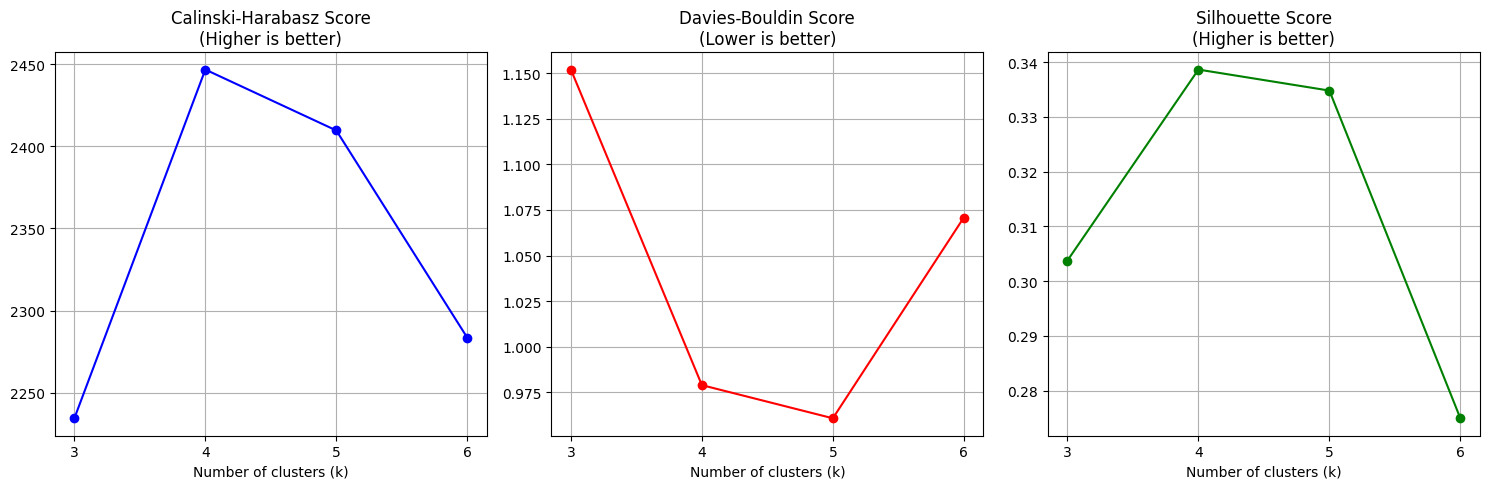

Optimal k according to Calinski-Harabasz (Max): 4
Optimal k according to Davies-Bouldin (Min): 5
Optimal k according to Silhouette (Max): 4


In [7]:
# Define the range of k values you want to test
k_values = range(3, 7)

# Initialize lists to store the metrics
ch_scores = []
db_scores = []
sil_scores = []
cluster_results = {}

# Calculate metrics for each k
for k in k_values:
    # Run K-means on the FAMD data
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_famd)
    cluster_results[k] = labels
    
    # Calculate and store the three scores
    ch_scores.append(calinski_harabasz_score(X_famd, labels))
    db_scores.append(davies_bouldin_score(X_famd, labels))
    sil_scores.append(silhouette_score(X_famd, labels))

# Plot evaluation metrics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Calinski-Harabasz (Higher is better)
ax1.plot(k_values, ch_scores, 'bo-')
ax1.set_title('Calinski-Harabasz Score\n(Higher is better)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_xticks(k_values)
ax1.grid(True)

# Davies-Bouldin (Lower is better)
ax2.plot(k_values, db_scores, 'ro-')
ax2.set_title('Davies-Bouldin Score\n(Lower is better)')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_xticks(k_values)
ax2.grid(True)

# Silhouette (Higher is better)
ax3.plot(k_values, sil_scores, 'go-')
ax3.set_title('Silhouette Score\n(Higher is better)')
ax3.set_xlabel('Number of clusters (k)')
ax3.set_xticks(k_values)
ax3.grid(True)

plt.tight_layout()
plt.show()

# Print optimal values automatically
best_ch_k = k_values[np.argmax(ch_scores)]
best_db_k = k_values[np.argmin(db_scores)]
best_sil_k = k_values[np.argmax(sil_scores)]

print(f"Optimal k according to Calinski-Harabasz (Max): {best_ch_k}")
print(f"Optimal k according to Davies-Bouldin (Min): {best_db_k}")
print(f"Optimal k according to Silhouette (Max): {best_sil_k}")

# K-Means Clustering

**Thanks to FAMD, we can now use K-Means**, the standard clustering algorithm based on Euclidean distances.

To begin visualizing the results of the K-Means algorithm, the code produces:

* A **2D scatter plot of the two principal dimensions**, which are the dimensions that explain the majority of the variance.

* A **3D scatter plot of the three principal dimensions**,

* A table showing the values of the active_cols and some other important feature for each cluster.

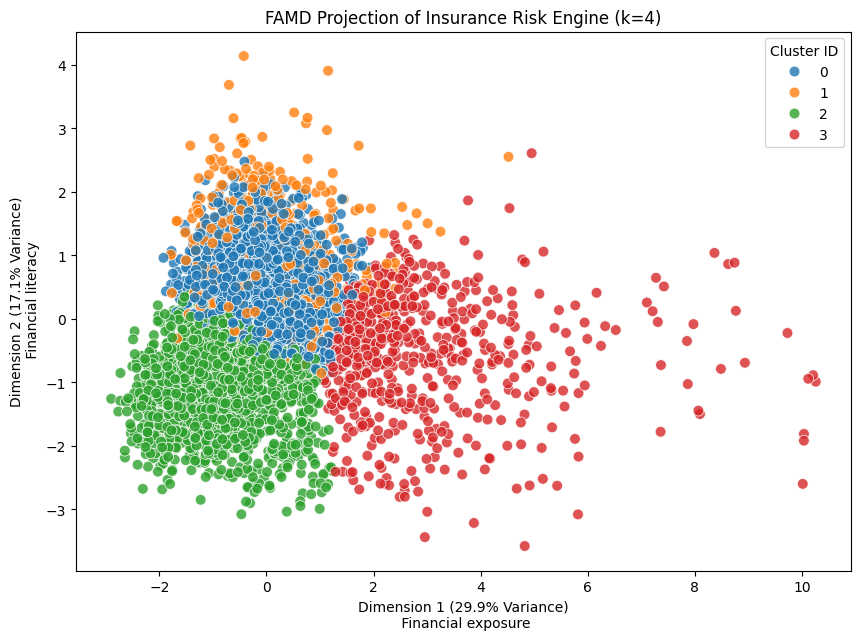

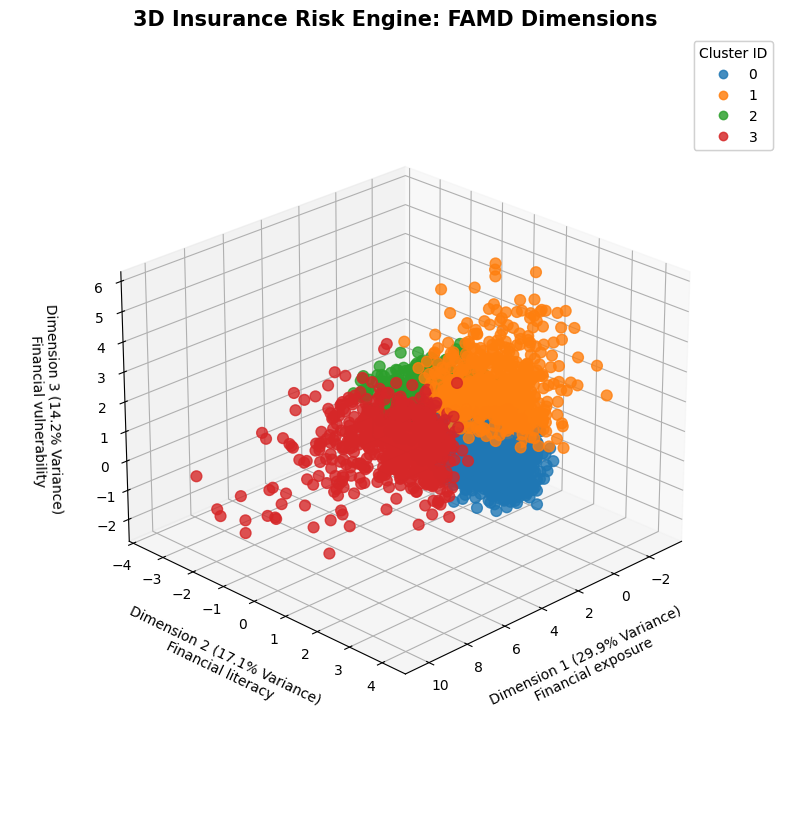

--- THE FINANCIAL PERSONAS (Averages by Cluster) ---


,Wealth,Income,Debt,Saving,FamilySize,Job,Debt_to_Income,Safety_Net,Dependents_Risk,Asset_Exposure,FinEdu
Cluster_ID,,,,,,,,,,,
0,0.66,0.69,0.53,0.58,1,2,0.81,1.89,0.04,0.87,0.65
1,0.57,0.60,0.47,0.53,4,2,0.85,1.96,0.13,0.81,0.48
2,0.47,0.52,0.26,0.43,1,5,0.51,1.87,0.03,0.66,0.34
3,0.57,0.28,0.46,0.54,1,2,1.72,3.98,0.05,1.80,0.46


In [8]:
# We set k=4 from the later scores that we in the next part as it is optimal for this one
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_famd)


# Plot the Manifold (SCATTER PLOT 2D)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_famd['Dim_1'], 
    y=X_famd['Dim_2'], 
    hue=cluster_labels, 
    palette='tab10', 
    s=60, alpha=0.8
)

plt.title(f'FAMD Projection of Insurance Risk Engine (k={optimal_k})')
plt.xlabel(f'Dimension 1 ({explained_variance[0]:.1f}% Variance)\n Financial exposure')
plt.ylabel(f'Dimension 2 ({explained_variance[1]:.1f}% Variance)\n Financial literacy')
plt.legend(title='Cluster ID')


# 3D PLOT
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_famd['Dim_1'], 
    X_famd['Dim_2'], 
    X_famd['Dim_3'],
    c=cluster_labels, 
    cmap='tab10',
    vmin=0, vmax=9,     
    s=60,
    alpha=0.8,
)

# Labeling and Aesthetics
ax.set_title('3D Insurance Risk Engine: FAMD Dimensions', fontsize=15, fontweight='bold')
ax.set_xlabel(f'Dimension 1 ({explained_variance[0]:.1f}% Variance)\n Financial exposure', labelpad=20)
ax.set_ylabel(f'Dimension 2 ({explained_variance[1]:.1f}% Variance)\n Financial literacy', labelpad=20)
ax.set_zlabel(f'Dimension 3 ({explained_variance[2]:.1f}% Variance)\n Financial vulnerability', labelpad=20)

legend = ax.legend(*scatter.legend_elements(), title="Cluster ID")
ax.add_artist(legend)

ax.set_box_aspect(None, zoom=0.8)

ax.view_init(elev=25, azim=45)
plt.show()


# Map the clusters back to the ORIGINAL dataframe
data['Cluster_ID'] = cluster_labels

print("--- THE FINANCIAL PERSONAS (Averages by Cluster) ---")
profile_active = data.groupby('Cluster_ID').agg({
    # Raw stats
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'FamilySize': lambda x: x.mode()[0],
    'Job': lambda x: x.mode()[0],
    
    # NEW: Add the engineered ratios here so the dashboard can see them!
    'Debt_to_Income': 'mean',
    'Safety_Net': 'mean',
    'Dependents_Risk': 'mean',
    'Asset_Exposure': 'mean',
    'FinEdu': 'mean' 
}).round(2)

display(profile_active)

# Interpreting the Results

After applying K-Means clustering with our optimal $k=4$, we perform a thorough statistical examination of the clusters. To gain clear visual insights and a comprehensive overview of each cluster's characteristics, we will generate multiple complementary plots:

* **Heatmap**

* **Bar Chart (Job distribution)**

* **Grouped Bar Chart**

* **Radar Chart**

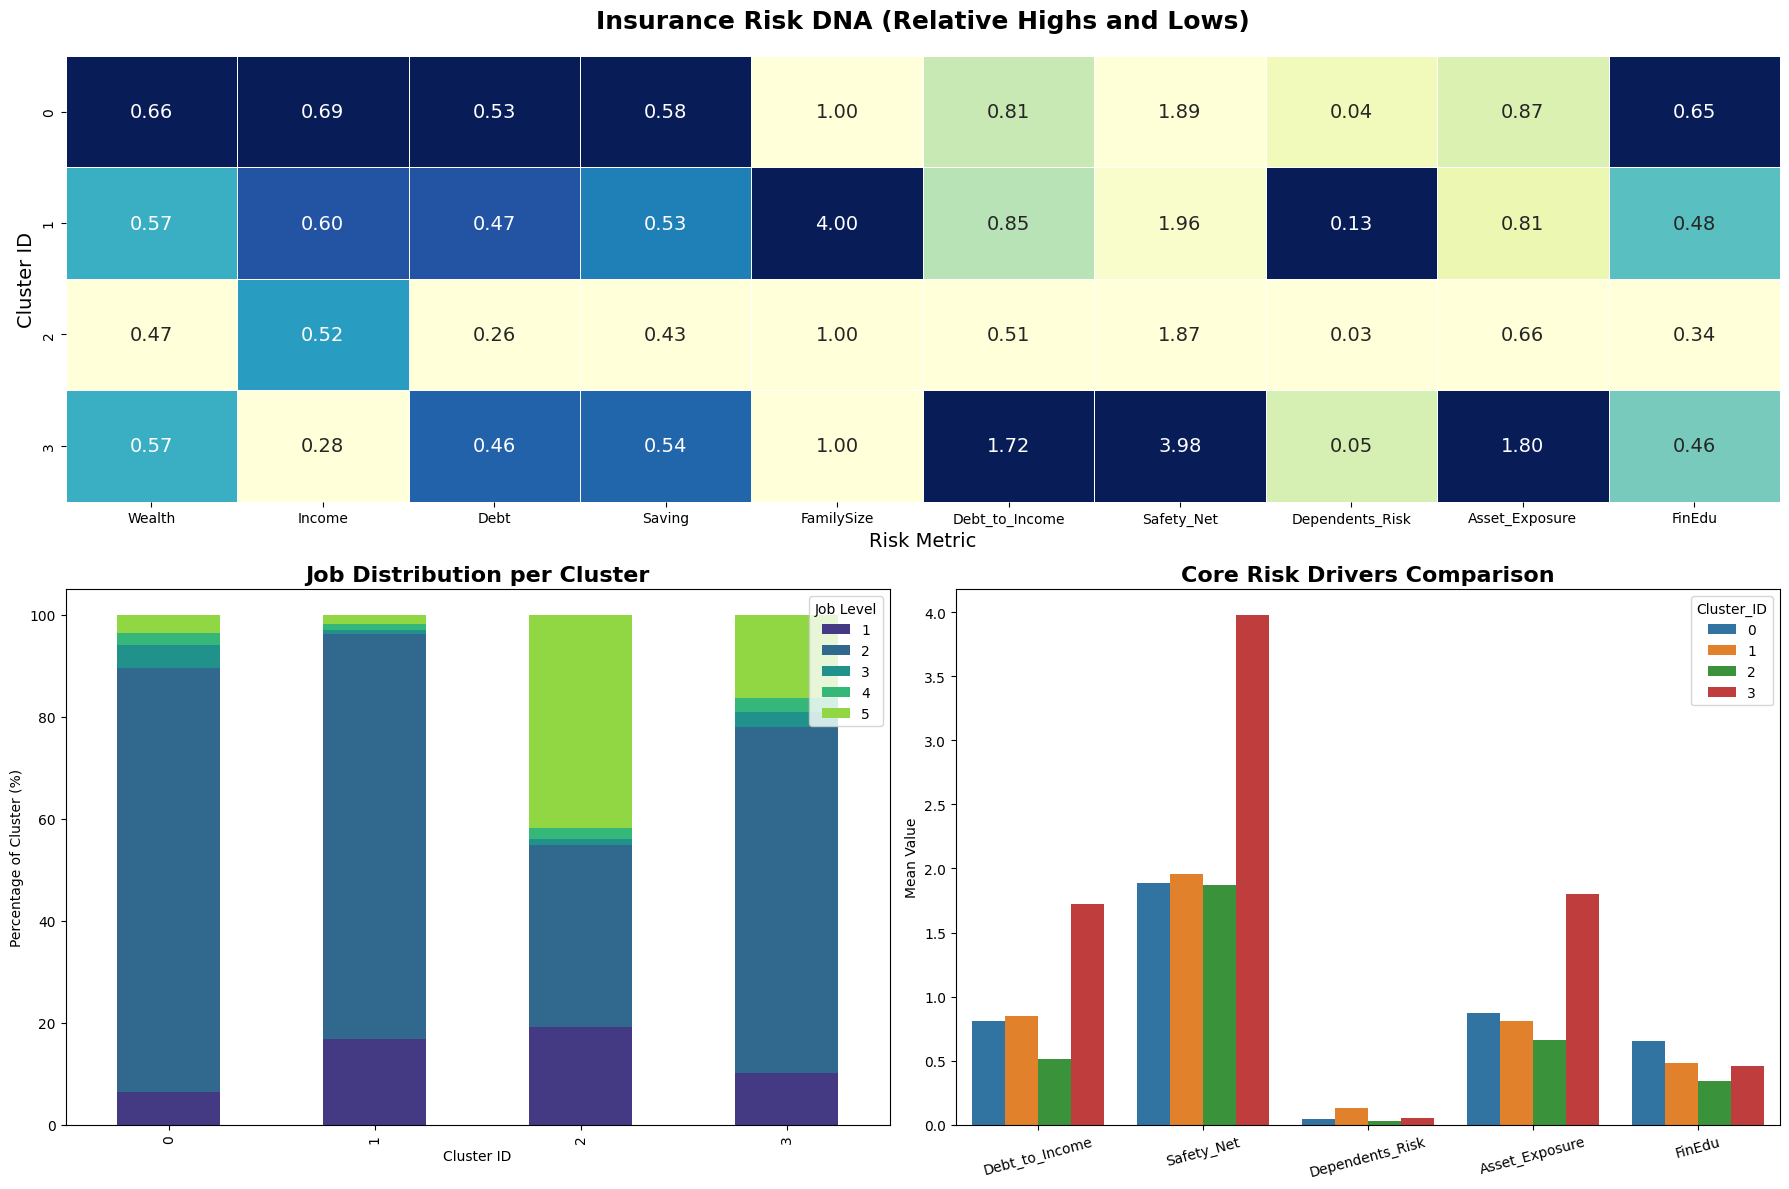

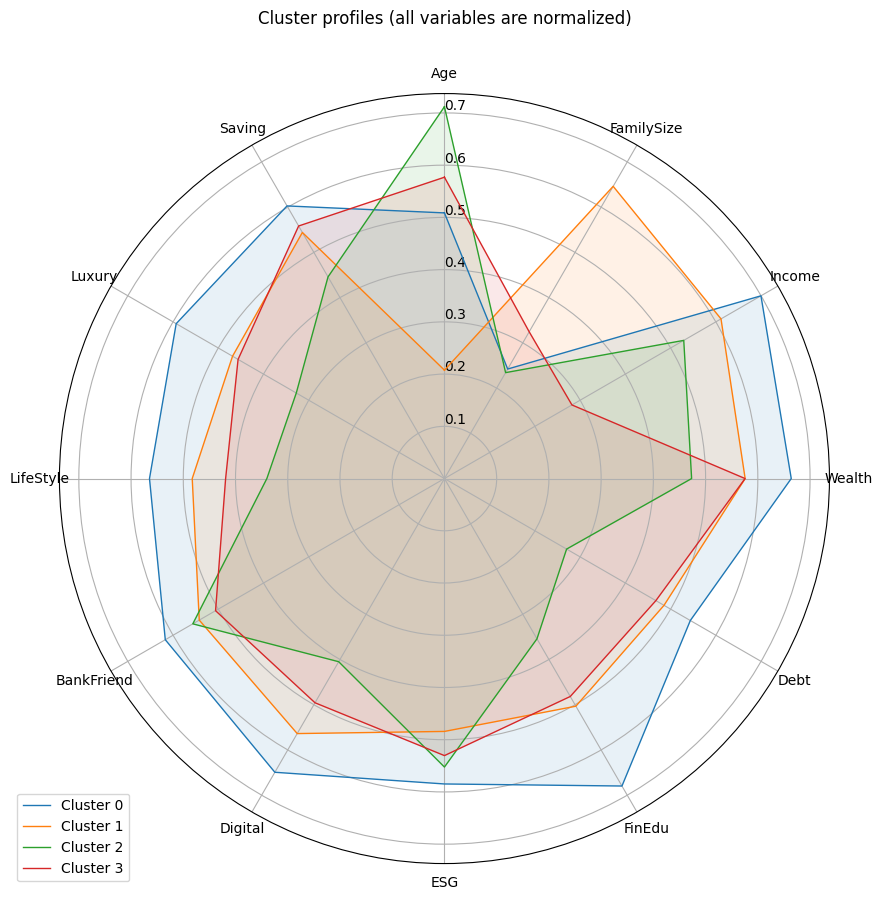

In [9]:
# 1. Prepare the Data
# We exclude 'Job' for the heatmap because it's categorical
num_profile = profile_active.drop(columns=['Job'])

# Scale the means (0 to 1) just for the heatmap colors to ensure 
# high values are dark and low values are light across different scales.
scaler = MinMaxScaler()
scaled_profile = pd.DataFrame(
    scaler.fit_transform(num_profile), 
    columns=num_profile.columns, 
    index=num_profile.index
)


# INSURANCE RISK PERSONA DASHBOARD
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# A. THE HEATMAP (The "Pattern" View)
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(scaled_profile, annot=num_profile, fmt=".2f", cmap="YlGnBu", 
            cbar=False, linewidths=.5, ax=ax0, annot_kws={"size": 14})
ax0.set_title("Insurance Risk DNA (Relative Highs and Lows)", fontsize=18, fontweight='bold', pad=20)
ax0.set_xlabel("Risk Metric", fontsize=14)
ax0.set_ylabel("Cluster ID", fontsize=14)

# B. THE CATEGORICAL TARGET (Job Level)
ax1 = fig.add_subplot(gs[1, 0])
# We look at the actual distribution of Jobs for each cluster
inv_dist = pd.crosstab(data['Cluster_ID'], data['Job'], normalize='index') * 100
inv_dist.plot(kind='bar', stacked=True, ax=ax1, color=sns.color_palette("viridis", 5))
ax1.set_title("Job Distribution per Cluster", fontsize=16, fontweight='bold')
ax1.set_ylabel("Percentage of Cluster (%)")
ax1.set_xlabel("Cluster ID")
ax1.legend(title="Job Level", loc='upper right')

# C. THE COMPARISON (New Risk Ratios)
ax2 = fig.add_subplot(gs[1, 1])
# Melting for a grouped bar chart using our NEW engineered columns
new_risk_cols = ['Debt_to_Income', 'Safety_Net', 'Dependents_Risk', 'Asset_Exposure', 'FinEdu']
melted_active = num_profile[new_risk_cols].reset_index().melt(id_vars='Cluster_ID')

sns.barplot(data=melted_active, x='variable', y='value', hue='Cluster_ID', ax=ax2, palette='tab10')
ax2.set_title("Core Risk Drivers Comparison", fontsize=16, fontweight='bold')
ax2.set_ylabel("Mean Value")
ax2.set_xlabel("")
ax2.tick_params(axis='x', rotation=15) # Slightly rotate labels since they are longer now

plt.tight_layout()
plt.show()


# RADAR Chart
radar_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = cluster_labels

def plot_cluster_radar(data):
    # Create a copy of the data for normalization
    plot_data = data.copy()
    
    # Normalize all numerical variables using MinMaxScaler
    scaler = MinMaxScaler()
    plot_data[radar_cols] = scaler.fit_transform(plot_data[radar_cols])
    
    # Calculate mean values for each numerical variable by cluster
    cluster_means = plot_data.groupby('Cluster')[radar_cols].mean()
    
    # Set up the radar chart
    categories = radar_cols
    num_vars = len(categories)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Plot for each cluster
    for cluster in range(4):
        values = cluster_means.loc[cluster].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {cluster}')
        ax.fill(angles, values, alpha=0.1)
    
    # Set chart properties
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)
    plt.xticks(angles[:-1], categories)
    ax.set_title("Cluster profiles (all variables are normalized)", y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    
    plt.show()

# Execute visualizations
plot_cluster_radar(data_with_clusters)


# Cluster 0

In [10]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id].copy()

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])


# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 0 ---
Average Age: 57.7
Most common Gender: 0
Digital Propensity: 0.63
BankFriend Propensity: 0.65
Most common Area: 1
Most common CitySize: 3
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 0 ---

--- Gender Distribution ---
Gender
0    50.6%
1    49.4%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    76.2%
2    13.5%
3    10.4%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
3    39.3%
2    36.0%
1    24.7%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend
mean  57.655812  0.631033    0.653995
min   19.000000  0.060530    0.158130
50%   56.000000  0.646948    0.669520
max   95.000000  0.960109    0.974230
--- VOLUME SUMMARY FOR CLUSTER 0 ---
Total People in Cluster: 2211
Percentage of Total Base: 44.3%
----------------------------------------


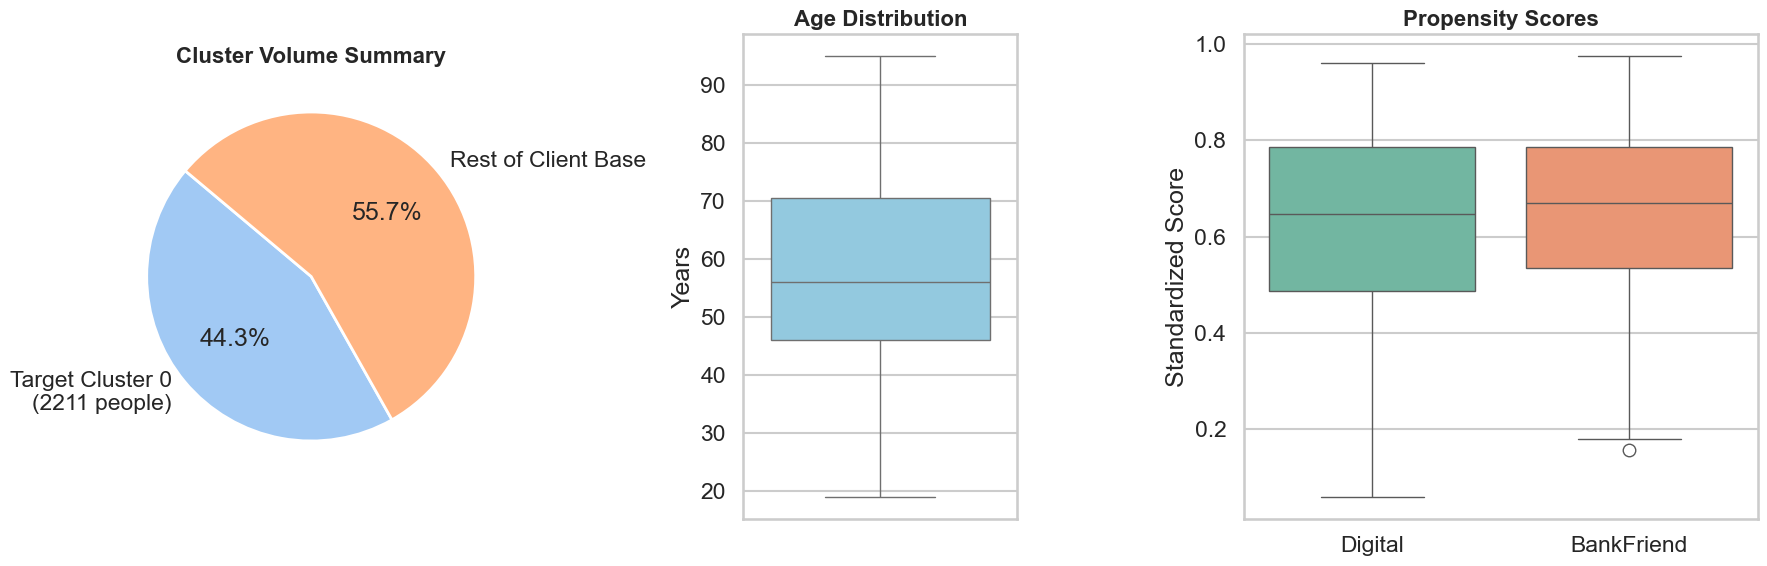

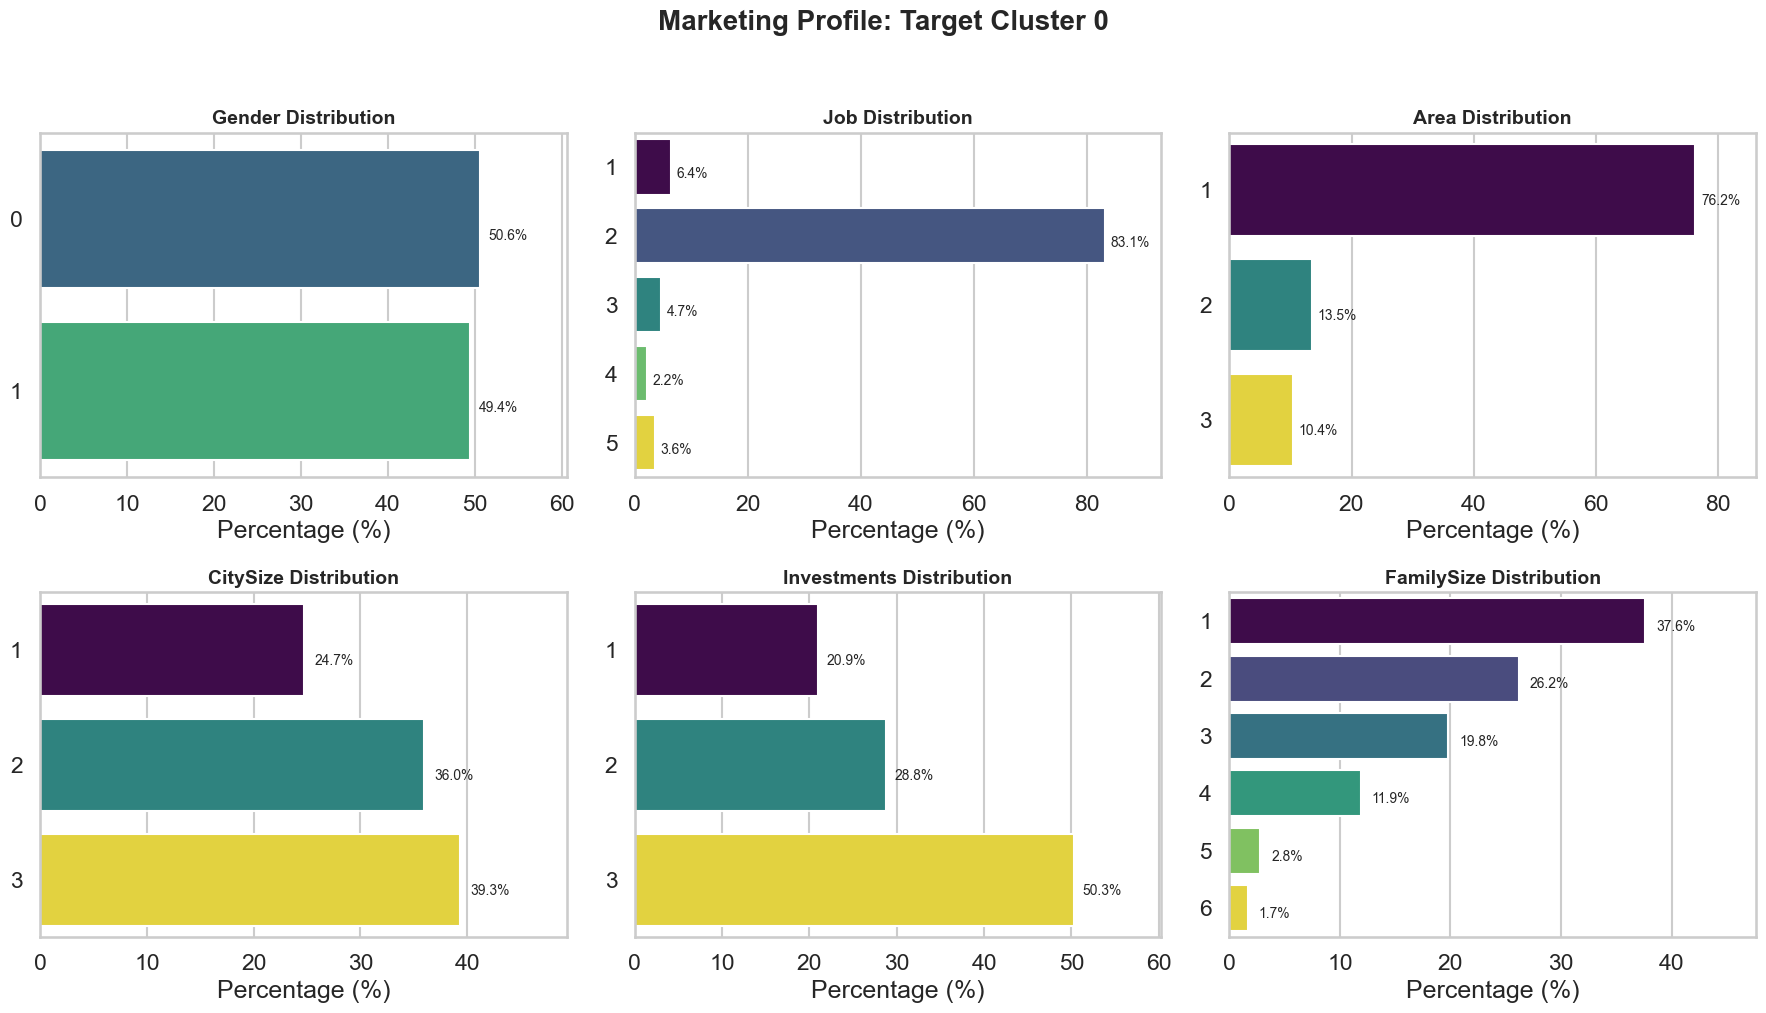

In [11]:
# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# Setup Variables
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# VOLUME & NUMERICAL TRAITS
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2', hue='Feature', legend=False)
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()


# CATEGORICAL DISTRIBUTIONS
target_profile['Job'] = data.loc[target_profile.index, 'Job']
target_profile['FamilySize'] = data.loc[target_profile.index, 'FamilySize']
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h', hue=dist.index, legend=False)
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cluster 1

In [12]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster
target_cluster_id = 1
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id].copy()

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])


# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 1 ---
Average Age: 34.8
Most common Gender: 1
Digital Propensity: 0.55
BankFriend Propensity: 0.59
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 1 ---

--- Gender Distribution ---
Gender
1    50.9%
0    49.1%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    69.4%
2    16.0%
3    14.5%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    46.7%
1    36.7%
3    16.5%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend
mean  34.774624  0.547874    0.591183
min   19.000000  0.000000    0.208111
50%   31.000000  0.544724    0.595606
max   93.000000  0.971778    0.961477
--- VOLUME SUMMARY FOR CLUSTER 1 ---
Total People in Cluster: 599
Percentage of Total Base: 12.0%
----------------------------------------


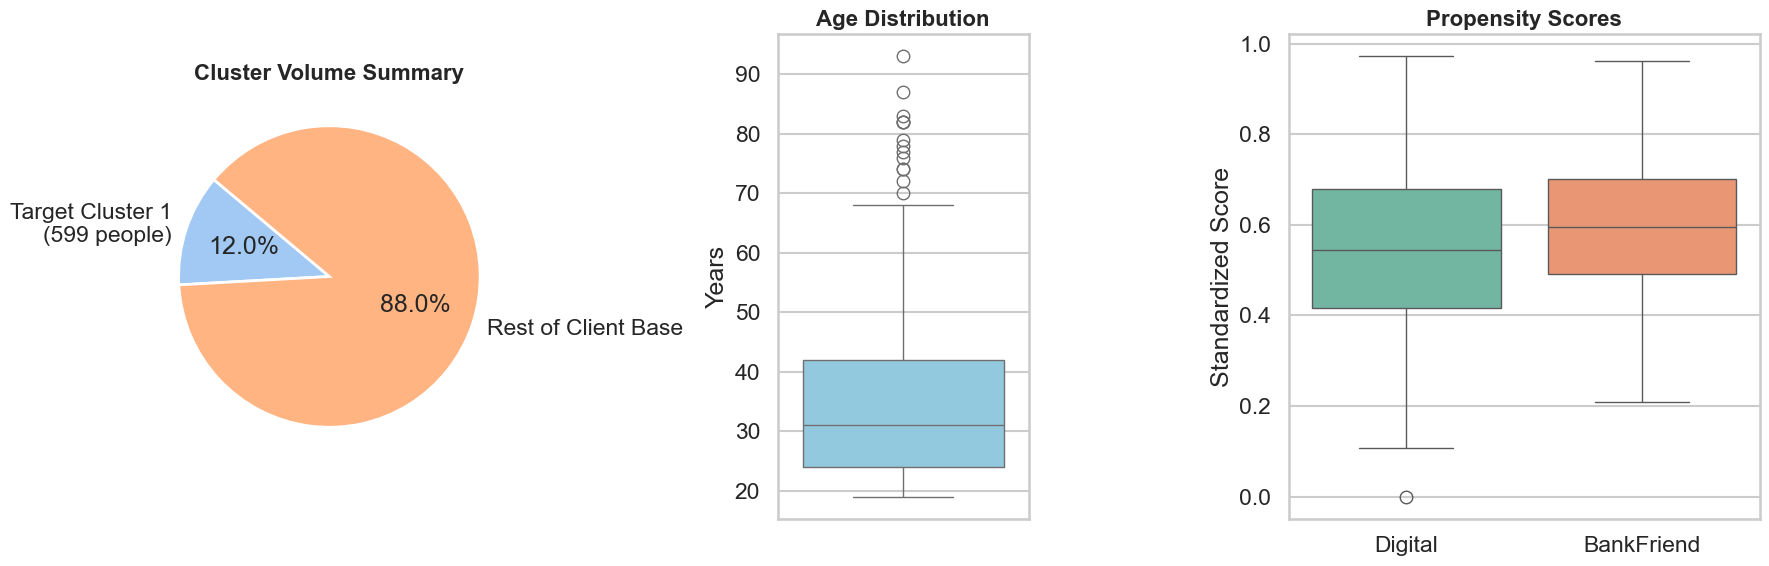

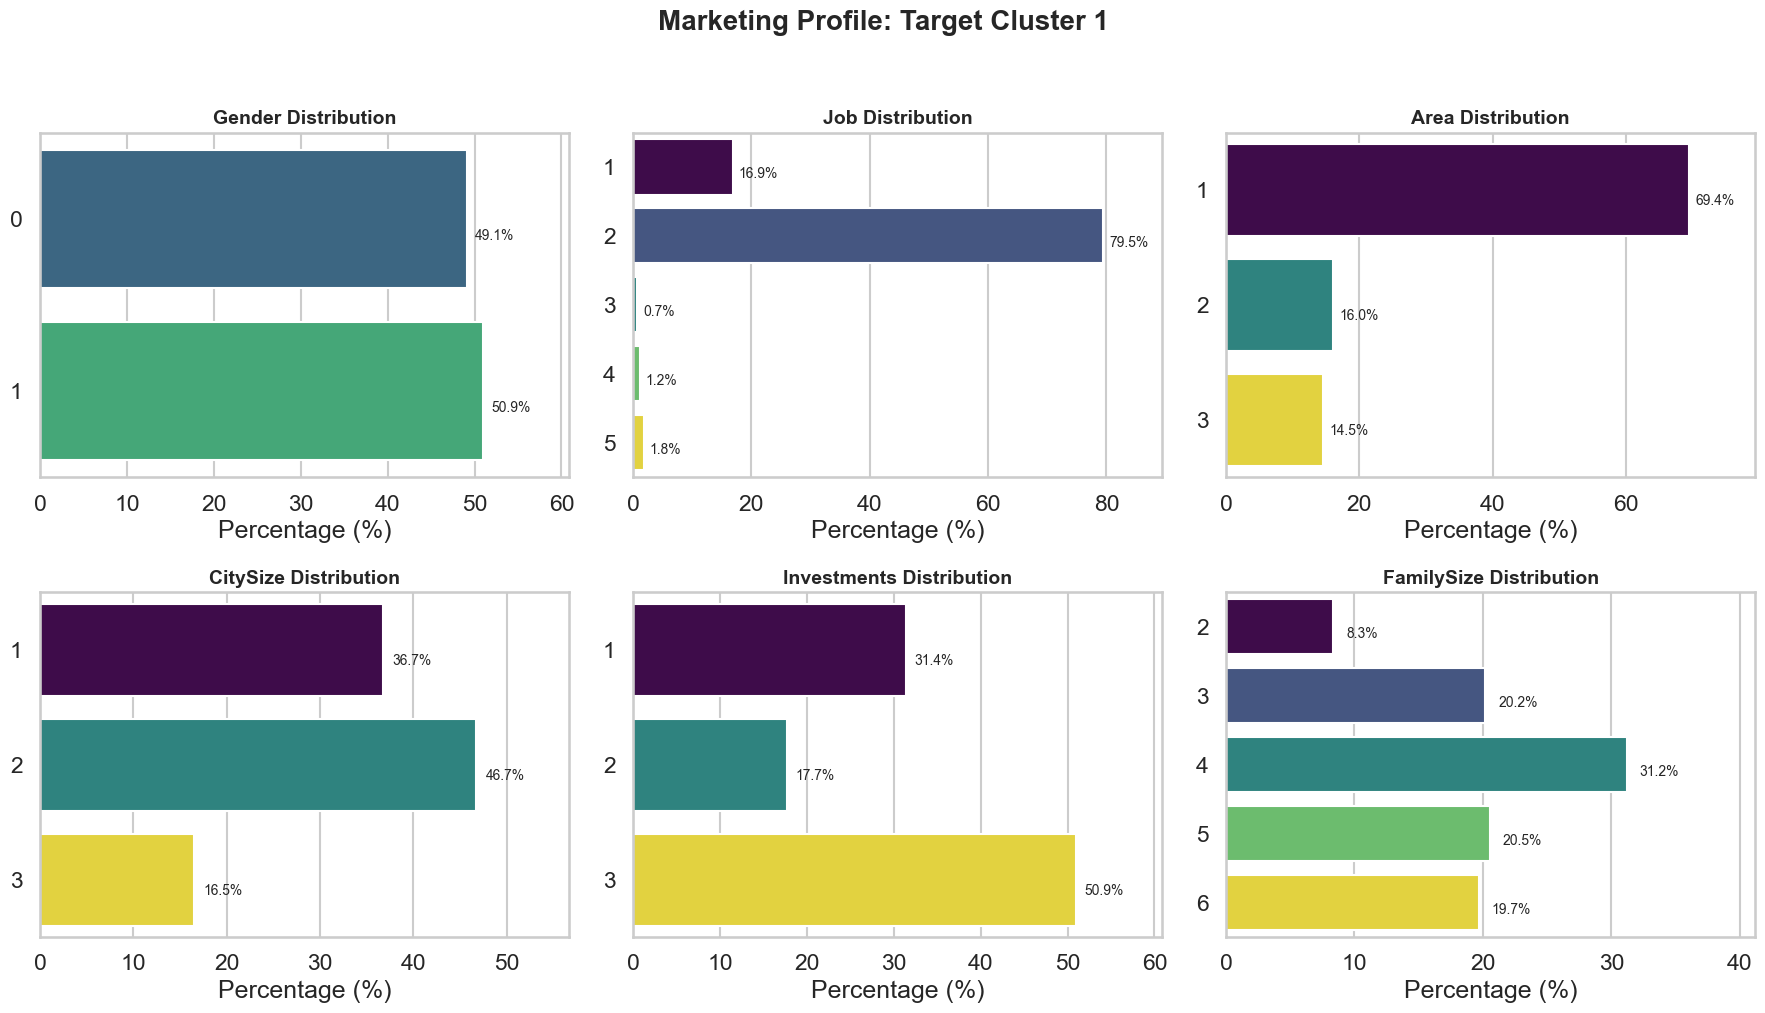

In [13]:
# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# Setup Variables
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# VOLUME & NUMERICAL TRAITS
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2', hue='Feature', legend=False)
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()


# CATEGORICAL DISTRIBUTIONS
target_profile['Job'] = data.loc[target_profile.index, 'Job']
target_profile['FamilySize'] = data.loc[target_profile.index, 'FamilySize']
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h', hue=dist.index, legend=False)
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cluster 2

In [14]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster
target_cluster_id = 2
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id].copy()

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])


# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 2 ---
Average Age: 73.1
Most common Gender: 1
Digital Propensity: 0.39
BankFriend Propensity: 0.60
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 2 ---

--- Gender Distribution ---
Gender
1    57.7%
0    42.3%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    68.3%
2    21.4%
3    10.3%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    46.1%
1    40.0%
3    13.8%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend
mean  73.104803  0.393510    0.603109
min   19.000000  0.000000    0.166759
50%   77.000000  0.379370    0.608427
max   95.000000  0.969335    0.972129
--- VOLUME SUMMARY FOR CLUSTER 2 ---
Total People in Cluster: 1603
Percentage of Total Base: 32.1%
----------------------------------------


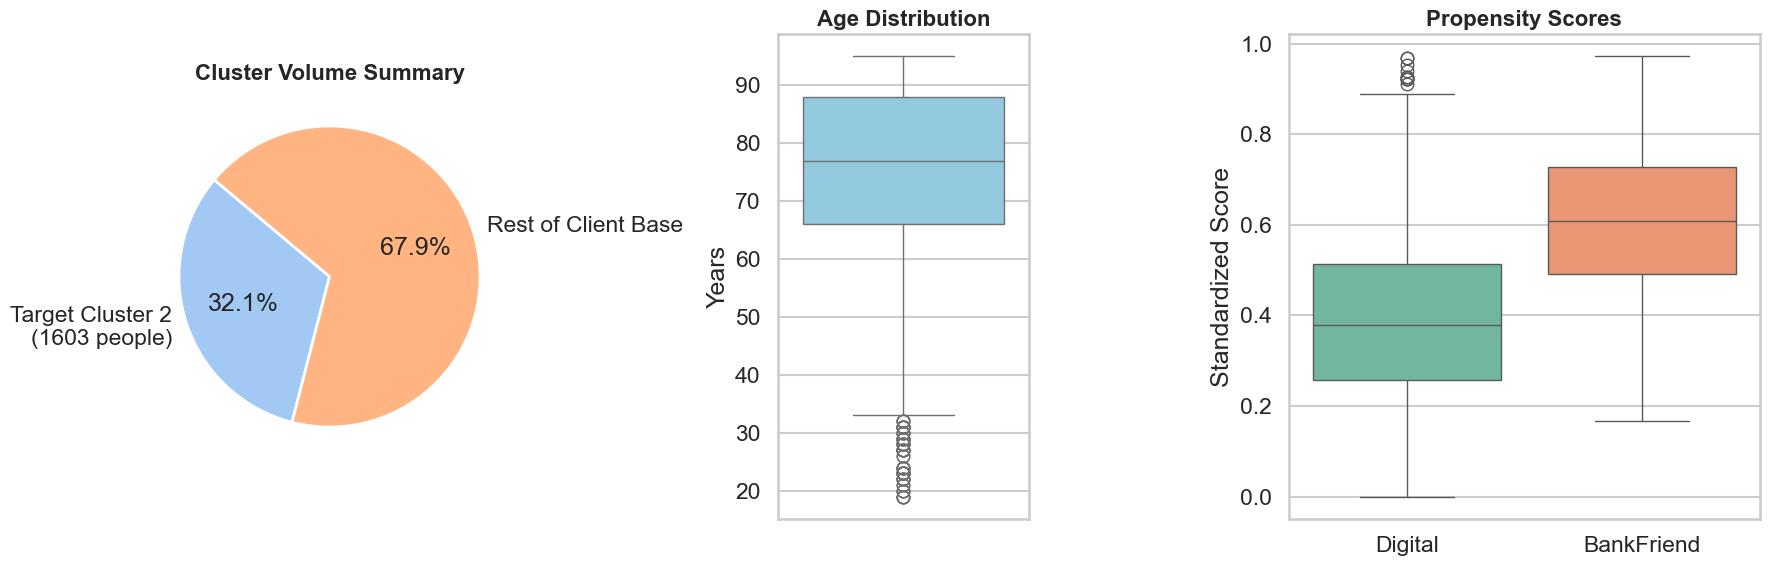

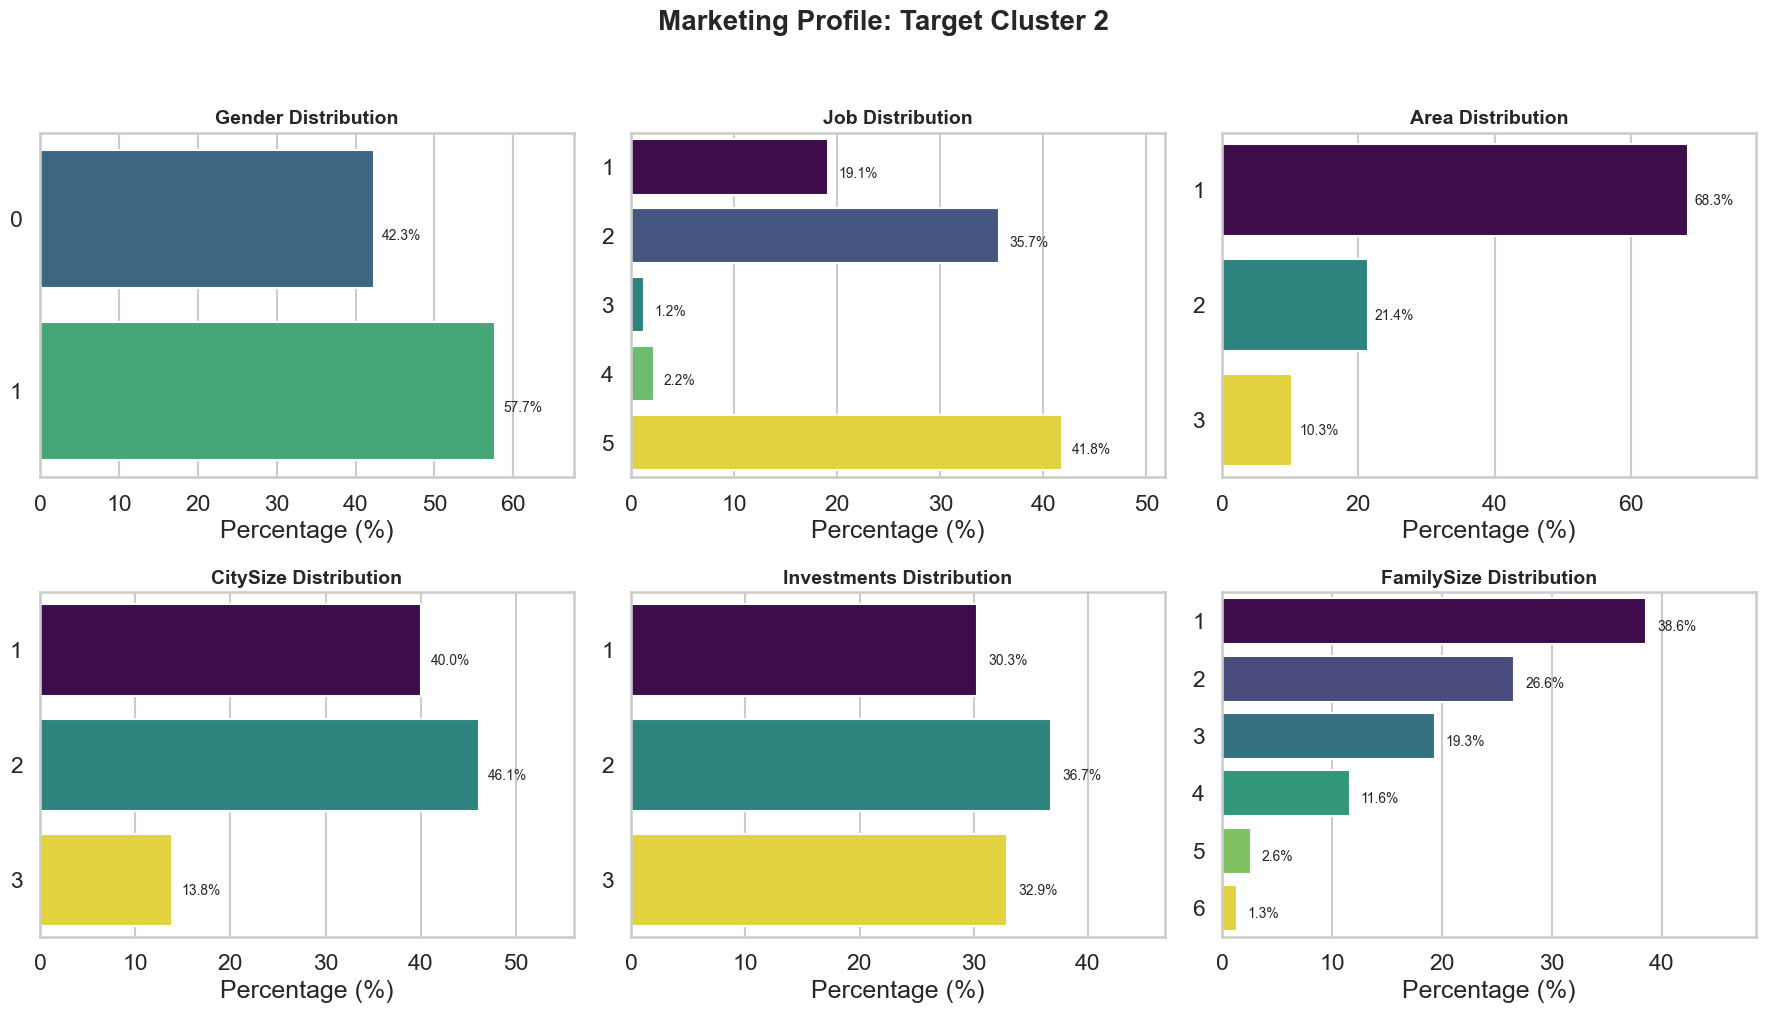

In [15]:
# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# Setup Variables
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# VOLUME & NUMERICAL TRAITS
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2', hue='Feature', legend=False)
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()


# CATEGORICAL DISTRIBUTIONS
target_profile['Job'] = data.loc[target_profile.index, 'Job']
target_profile['FamilySize'] = data.loc[target_profile.index, 'FamilySize']
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h', hue=dist.index, legend=False)
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cluster 3

In [16]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster
target_cluster_id = 3
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id].copy()

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])


# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 3 ---
Average Age: 62.8
Most common Gender: 1
Digital Propensity: 0.48
BankFriend Propensity: 0.56
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 3 ---

--- Gender Distribution ---
Gender
1    54.1%
0    45.9%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    73.1%
2    14.8%
3    12.1%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    42.2%
1    41.9%
3    15.9%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend
mean  62.846552  0.481708    0.561036
min   19.000000  0.000000    0.137763
50%   67.000000  0.474881    0.568671
max   95.000000  0.942878    0.891410
--- VOLUME SUMMARY FOR CLUSTER 3 ---
Total People in Cluster: 580
Percentage of Total Base: 11.6%
----------------------------------------


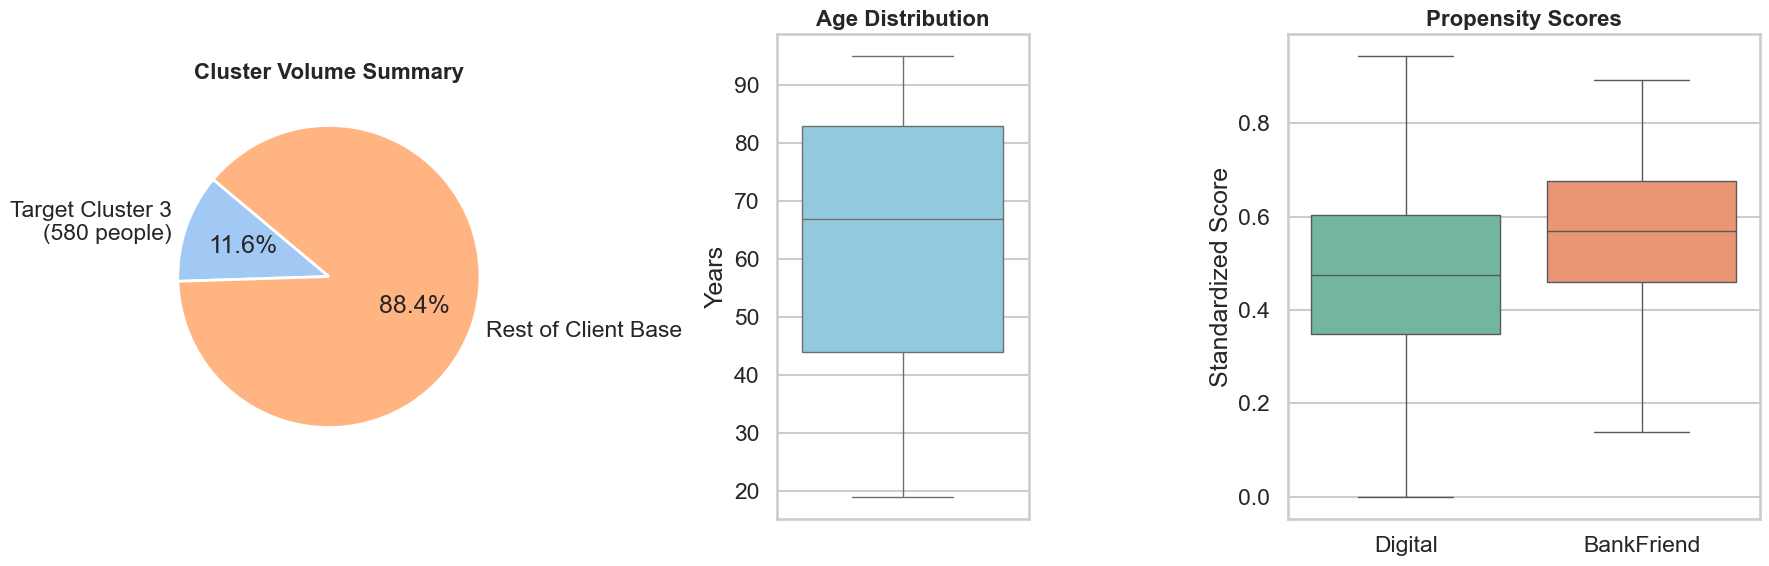

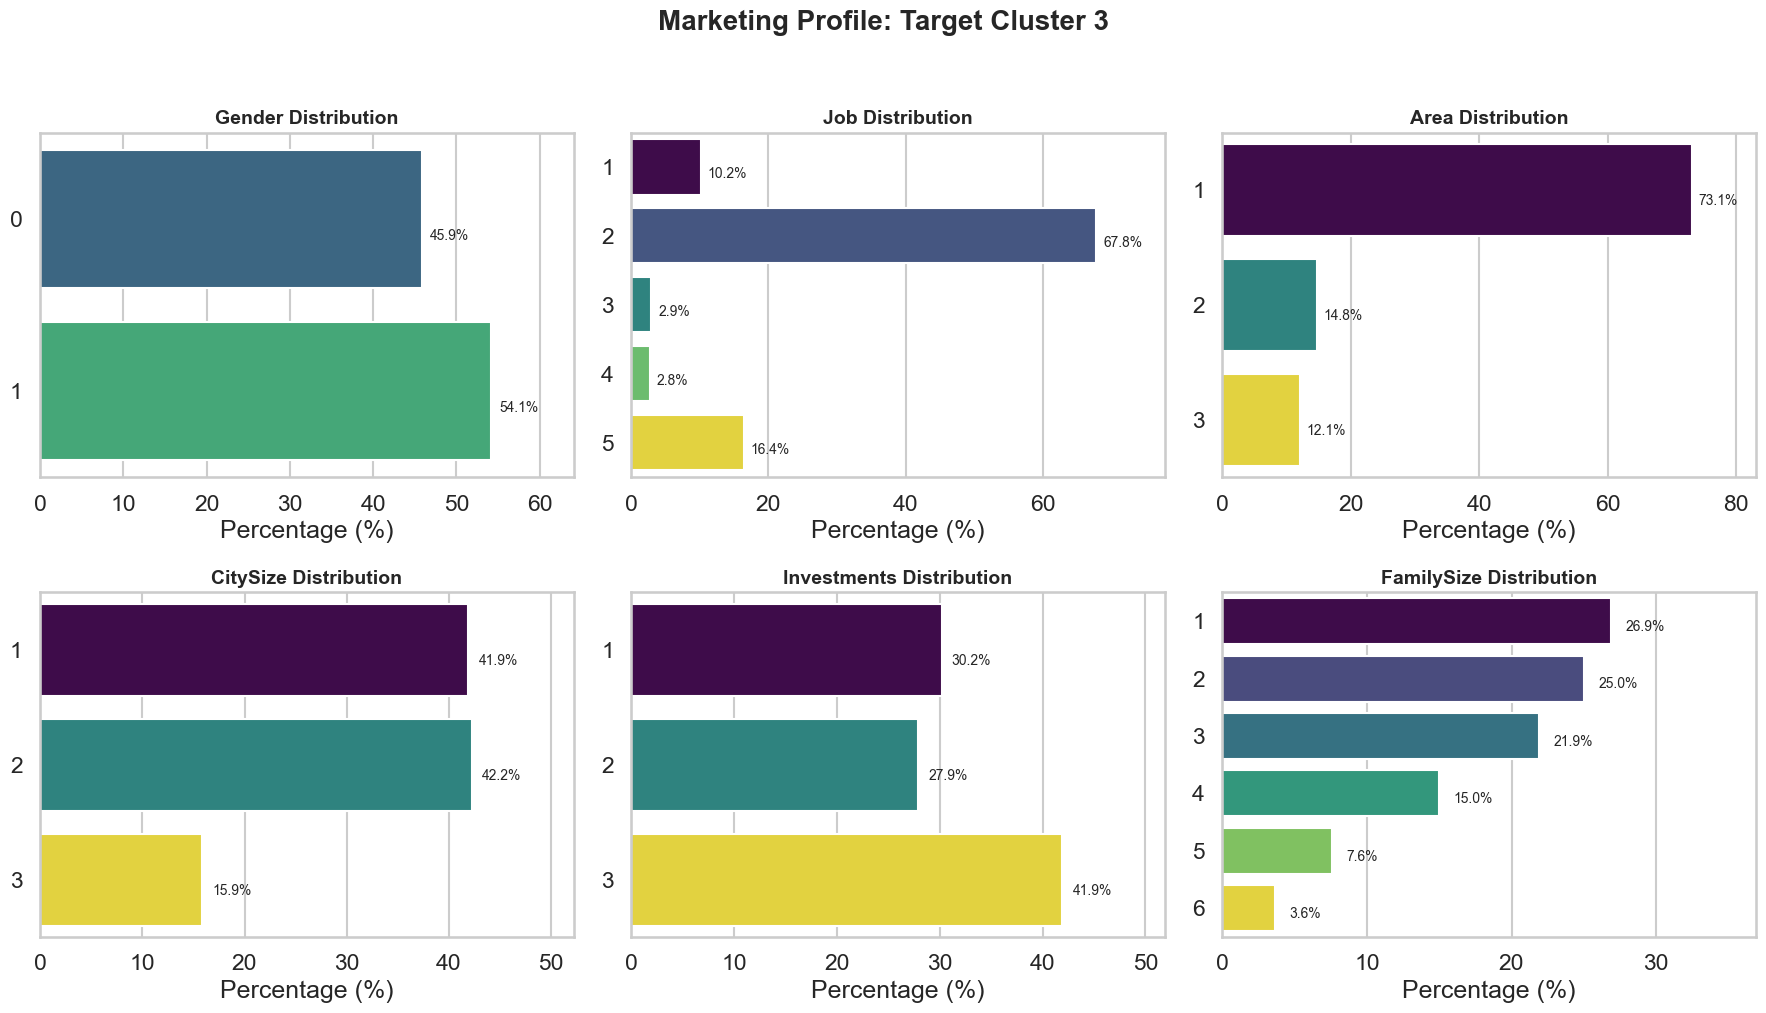

In [17]:
# Set the visual style for the dashboard
sns.set_theme(style="whitegrid", context="talk")

# Setup Variables
total_count = len(df_passive_obj1)
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

# VOLUME & NUMERICAL TRAITS
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.2, 0.8, 1.5]})

# Pie Chart for Volume
labels = [f'Target Cluster {target_cluster_id}\n({cluster_count} people)', 'Rest of Client Base']
sizes = [cluster_count, total_count - cluster_count]
colors = sns.color_palette('pastel')[0:2]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f"Cluster Volume Summary", fontsize=16, fontweight='bold')

# Boxplot strictly for AGE
sns.boxplot(data=target_profile, y='Age', ax=axes[1], color='skyblue')
axes[1].set_title("Age Distribution", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Years")

# Boxplots strictly for STANDARDIZED SCORES
scaled_cols = ['Digital', 'BankFriend']
melted_scaled = target_profile[scaled_cols].melt(var_name='Feature', value_name='Score')

sns.boxplot(data=melted_scaled, x='Feature', y='Score', ax=axes[2], palette='Set2', hue='Feature', legend=False)
axes[2].set_title("Propensity Scores", fontsize=16, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Standardized Score")

plt.tight_layout()
plt.show()


# CATEGORICAL DISTRIBUTIONS
target_profile['Job'] = data.loc[target_profile.index, 'Job']
target_profile['FamilySize'] = data.loc[target_profile.index, 'FamilySize']
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments', 'FamilySize']

# Create a grid of subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to easily loop through them

for i, col in enumerate(cat_cols):
    # Calculate percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    
    # Create Horizontal Bar Plot
    sns.barplot(x=dist.values, y=dist.index, ax=axes[i], palette='viridis', orient='h', hue=dist.index, legend=False)
    
    # Formatting
    axes[i].set_title(f"{col} Distribution", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, max(dist.values) + 10) # Give a little breathing room on the right
    
    # Add exact percentage text labels onto the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2. + 0.1, 
                     f'{width:.1f}%', ha="left", va="center", fontsize=10)

fig.suptitle(f"Marketing Profile: Target Cluster {target_cluster_id}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Customer Profile Analysis - Personas

Through cluster analysis, we have identified each cluster with a specific persona as follows:

# Cluster 0: The Career Professional" (DINK Profile)
* **Demographics:** Medium-low age, small household (single or couple without children - *Double Income No Kids*).
* **Financial Situation:** Excellent level of **Income** and **Saving**. They strategically use financial leverage (high **Debt**, e.g., for mortgages or credit cards).
* **Lifestyle:** Strong propensity to spend on **Luxury** and **LifeStyle**.
* **Behavior:** Highly digitalized (high **Digital**) with excellent financial literacy (**FinEdu**). They combine this with a strong relationship of trust with their bank (**BankFriend**).

# Cluster 1: The "Young Parent"
* **Demographics:** Very low age, extremely large household (maximum peak in **FamilySize**).
* **Financial Situation:** Despite a good level of **Income**, their saving capacity (**Saving**) is at the absolute lowest level, eroded by high family management costs.
* **Lifestyle:** Spending on **Luxury** and **LifeStyle** is drastically reduced to prioritize family needs.
* **Behavior:** Very low level of financial literacy (**FinEdu**), indicating poor long-term wealth planning.

# Cluster 2: The "Cautious and Traditional Retiree"
* **Demographics:** Very high age (maximum peak on the chart), small household (retirees, widows/widowers).
* **Financial Situation:** This is the cluster with the lowest debt exposure overall (minimum **Debt**, indicating paid-off mortgages).
* **Lifestyle:** Frugal life, far from discretionary spending (low **Luxury** and **LifeStyle**). However, they show a surprising attention to sustainability issues (high **ESG**).
* **Behavior:** Very low propensity for digital tools (minimum **Digital**). They prefer human and traditional contact with the branch, recording a very high value in **BankFriend**.

# Cluster 3: The "Frugal Saver with Assets" (e.g., Homemaker / Rentier)
* **Demographics:** Medium-high age, average household size.
* **Financial Situation:** Almost non-existent monthly income (rock-bottom **Income**), but backed by solid real estate or financial assets (medium-high **Wealth**). They incredibly manage to keep their **Saving** almost at the maximum peak.
* **Lifestyle:** An existence extremely careful with expenses. Consumption for **Luxury** and **LifeStyle** is at a bare minimum.
* **Behavior:** Low financial literacy (**FinEdu**) and low digitalization. Their main focus is the pure preservation of accumulated capital, with no risk appetite.